In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/yellow_tripdata_2026.csv")
df

C:\Users\Linh\AppData\Local\Temp\ipykernel_12892\3070033926.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/yellow_tripdata_2026.csv")


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10483492,2,2026-03-31 23:10:43,2026-03-31 23:33:02,NaN,8.47,NaN,NaN,13,263,0,50.14,0.00,0.5,0.00,0.0,1.0,60.37,NaN,NaN,0.75
10483493,2,2026-03-31 23:41:22,2026-03-31 23:52:36,NaN,1.99,NaN,NaN,24,42,0,12.32,0.00,0.5,0.00,0.0,1.0,13.82,NaN,NaN,0.00
10483494,2,2026-03-31 23:39:38,2026-04-01 00:13:44,NaN,10.21,NaN,NaN,62,237,0,47.95,0.00,0.5,0.00,0.0,1.0,52.70,NaN,NaN,0.75
10483495,2,2026-03-31 23:57:57,2026-04-01 00:29:33,NaN,7.87,NaN,NaN,61,141,0,49.93,0.00,0.5,0.00,0.0,1.0,53.93,NaN,NaN,0.00


In [3]:
df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
)
df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"]
)

# Trip Distance 

In [5]:
df["trip_distance"].describe()

count    1.048350e+07
mean     3.475716e+00
std      4.241574e+00
min      1.000000e-02
25%      1.090000e+00
50%      1.900000e+00
75%      3.850000e+00
max      9.958000e+01
Name: trip_distance, dtype: float64

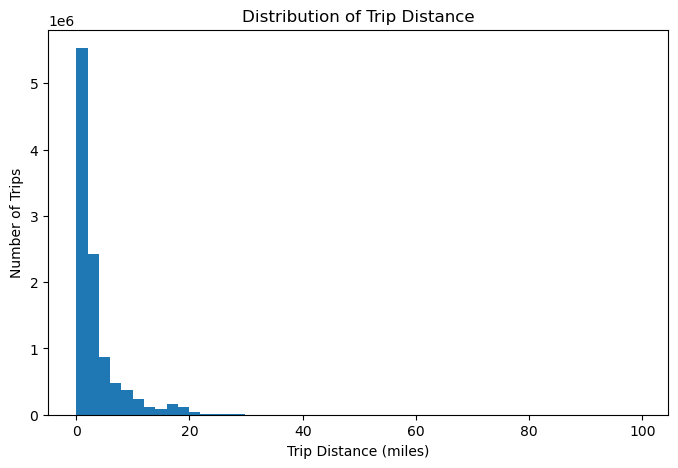

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["trip_distance"],
    bins=50
)

plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distance")

plt.show()

#### Nhận xét:
1. **Khoảng cách chuyến đi phổ biến nhất**:
- Phần lớn các chuyến đi có khoảng cách rất ngắn, tập trung chủ yếu trong khoảng 0–3 dặm (miles).Đa số các chuyến taxi là các chuyến đi ngắn, với khoảng cách dưới 3 dặm, 50% số chuyến đi có khoảng cách không quá 1,9 dặm, 25% số chuyến có khoảng cách dưới 1,09 dặm. Điều này cho thấy người dân chủ yếu sử dụng taxi cho các nhu cầu di chuyển trong phạm vi gần.
2. **Mức độ phân bố của khoảng cách**:
- Tần suất giảm rất nhanh khi khoảng cách tăng, 75% số chuyến đi có khoảng cách không quá 3,85 dặm.
- Phân bố khoảng cách chuyến đi không đồng đều mà tập trung mạnh vào các chuyến đi ngắn. Khi khoảng cách tăng, số lượng chuyến đi giảm nhanh.

=> Thành phố New York có mật độ dân cư cao và hệ thống giao thông dày đặc, nên nhiều người sử dụng taxi để di chuyển giữa các địa điểm gần nhau như nơi làm việc, trung tâm thương mại, nhà hàng hoặc điểm du lịch. Các chuyến đi dài thường là các chuyến đến sân bay, ngoại ô hoặc các khu vực nằm ngoài trung tâm thành phố nên xuất hiện với tần suất thấp hơn.

# Fare Analysis

In [5]:
# Average fare 
avg_fare = df["fare_amount"].mean()

print(f"Average fare: ${avg_fare:.2f}")

Average fare: $21.40


In [7]:
median_fare = df["fare_amount"].median()

print(f"Median Fare: {median_fare:.2f} USD")

Median Fare: 15.60 USD


In [5]:
df_fare = df[df["trip_distance"] > 0].copy()

In [6]:
df_fare["fare_per_mile"] = (
    df_fare["fare_amount"] /
    df_fare["trip_distance"]
)

In [8]:
# tổng cước / tổng quãng đường
fare_per_mile = df_fare["fare_amount"].sum() / df_fare["trip_distance"].sum()

# Median của tỷ lệ từng chuyến 
median_fare_per_mile = df_fare["fare_per_mile"].median()

print(f"Fare per Mile : {fare_per_mile:.2f} USD/mile")
print(f"Median Fare per Mile     : {median_fare_per_mile:.2f} USD/mile")


Fare per Mile : 6.16 USD/mile
Median Fare per Mile     : 7.66 USD/mile


#### Nhận xét:

* **Giá cước trung bình (Average Fare)** của một chuyến đi là **21,40 USD**, trong khi **giá cước trung vị (Median Fare)** là **15,60 USD**. 
* **Giá cước trên mỗi mile (tính bằng tổng cước / tổng quãng đường)** là ~6,16 USD/mile, median ~7,66 USD/mile.

# Trip Duration 

In [14]:
df["trip_distance"].describe()

count    1.048350e+07
mean     3.475716e+00
std      4.241574e+00
min      1.000000e-02
25%      1.090000e+00
50%      1.900000e+00
75%      3.850000e+00
max      9.958000e+01
Name: trip_distance, dtype: float64

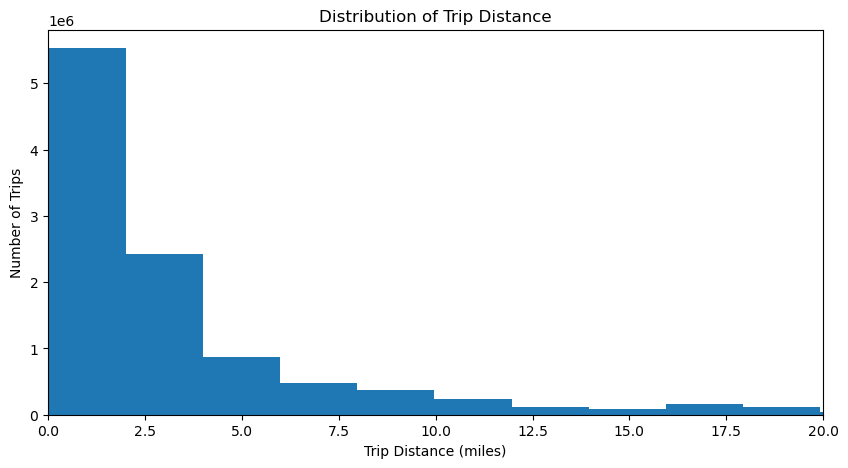

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df["trip_distance"],
    bins=50
)

plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distance")

plt.xlim(0,20)  

plt.show()

#### Nhận xét: 
1. **Khoảng cách chuyến đi phổ biến nhất**
- Phần lớn các chuyến taxi có khoảng cách dưới 2 miles.
- Tần suất cao nhất tập trung ở khoảng 0–1 dặm, sau đó giảm nhanh khi khoảng cách tăng, 50% số chuyến đi có khoảng cách không quá 1,9 dặm và 75% không vượt quá 3,85 dặm.
- Đa số các chuyến taxi là các chuyến đi ngắn, chủ yếu dưới 2–4 dặm. Điều này cho thấy taxi được sử dụng chủ yếu cho nhu cầu di chuyển trong nội thành với quãng đường ngắn.
- Các chuyến đi trên 10 dặm xuất hiện khá ít so với các chuyến đi ngắn.
- Khoảng cách chuyến đi không phân bố đồng đều mà tập trung chủ yếu ở các quãng đường ngắn. Càng đi xa, số lượng chuyến taxi càng giảm 

In [18]:
distance_group = pd.cut(
    df["trip_distance"],
    bins=[
        0,
        2,
        5,
        10,
        float("inf")
    ],
    labels=[
        "Short (<2 miles)",
        "Medium (2-5 miles)",
        "Long (5-10 miles)",
        "Very Long (>10 miles)"
    ]
)

distance_group.value_counts()

trip_distance
Short (<2 miles)         5530990
Medium (2-5 miles)       2947367
Long (5-10 miles)        1202038
Very Long (>10 miles)     803102
Name: count, dtype: int64

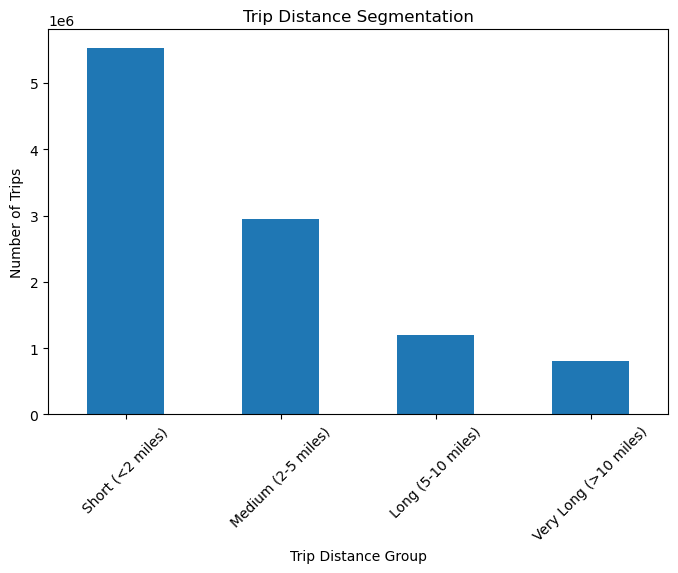

In [20]:
distance_group.value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.xlabel("Trip Distance Group")
plt.ylabel("Number of Trips")
plt.title("Trip Distance Segmentation")

plt.xticks(rotation=45)

plt.show()

#### Nhận xét:
1. Nhóm khoảng cách phổ biến nhất
- Nhóm Short (<2 miles) có số lượng chuyến đi cao nhất, khoảng 5,5 triệu chuyến. Số chuyến của nhóm này gần gấp đôi nhóm Medium (2–5 miles).
- Các chuyến đi ngắn dưới 2 dặm chiếm tỷ trọng lớn nhất, cho thấy phần lớn hành khách sử dụng taxi cho các quãng đường ngắn trong nội thành.
2. Phân bố theo nhóm khoảng cách 
- Số lượng chuyến giảm dần khi khoảng cách tăng.
- Thứ tự từ cao xuống thấp là:
    + Short (<2 miles)
    + Medium (2–5 miles)
    + Long (5–10 miles)
    + Very Long (>10 miles)
- Nhu cầu sử dụng taxi giảm dần theo khoảng cách chuyến đi. Các chuyến đi ngắn và trung bình chiếm phần lớn tổng số chuyến, trong khi các chuyến đi dài và rất dài xuất hiện ít hơn đáng kể.

=> New York là thành phố có mật độ dân cư cao và nhiều khu vực chức năng nằm gần nhau, nên taxi thường được lựa chọn cho các quãng đường ngắn và trung bình.

In [9]:
# Thời lượng chuyến đi (phút) = dropoff - pickup
df["duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["duration_min"].describe()


count    1.048350e+07
mean     1.742092e+01
std      1.421999e+01
min      1.666667e-02
25%      8.400000e+00
50%      1.370000e+01
75%      2.168333e+01
max      2.999000e+02
Name: duration_min, dtype: float64

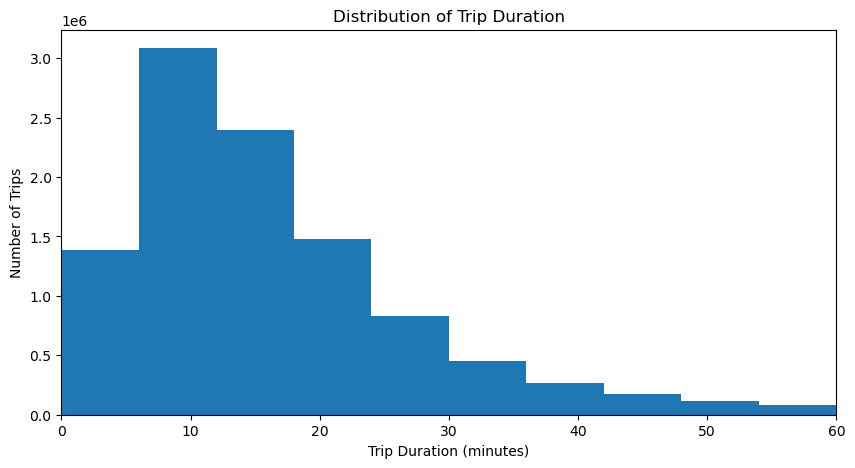

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.hist(df["duration_min"], bins=50)

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Duration")

plt.xlim(0, 60)  

plt.show()

In [12]:
duration_group = pd.cut(
    df["duration_min"],
    bins=[0, 5, 15, 30, 60, float("inf")],
    labels=[
        "Very Short (<5 min)",
        "Short (5-15 min)",
        "Medium (15-30 min)",
        "Long (30-60 min)",
        "Very Long (>60 min)"
    ]
)

duration_group.value_counts()


duration_min
Short (5-15 min)       4871140
Medium (15-30 min)     3379950
Long (30-60 min)       1093668
Very Short (<5 min)     921084
Very Long (>60 min)     217655
Name: count, dtype: int64

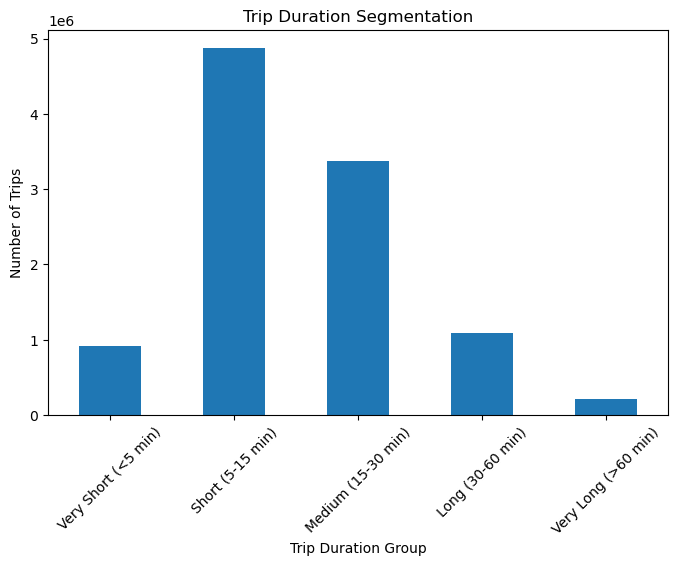

In [14]:
duration_group.value_counts(sort=False).plot(kind="bar", figsize=(8,5))

plt.xlabel("Trip Duration Group")
plt.ylabel("Number of Trips")
plt.title("Trip Duration Segmentation")
plt.xticks(rotation=45)
plt.show()

#### Địa điểm / tuyến đi phổ biến theo phân khúc quãng đường

In [4]:
# Tuyến đi (O-D) phổ biến nhất theo từng phân khúc quãng đường
import pandas as pd

# Map LocationID -> tên zone
taxi_zone = pd.read_csv("data/taxi_zone_lookup.csv")
zone_map = dict(zip(taxi_zone["LocationID"], taxi_zone["Zone"].fillna("Unknown")))

seg = df.copy()
seg["distance_group"] = pd.cut(
    seg["trip_distance"],
    bins=[0, 2, 5, 10, float("inf")],
    labels=["Short (<2 mi)", "Medium (2-5 mi)", "Long (5-10 mi)", "Very Long (>10 mi)"],
)
seg["pickup_zone"] = seg["PULocationID"].map(zone_map)
seg["dropoff_zone"] = seg["DOLocationID"].map(zone_map)
seg["route"] = seg["pickup_zone"] + "  →  " + seg["dropoff_zone"]

# Top 5 tuyến cho mỗi nhóm quãng đường
for g in seg["distance_group"].cat.categories:
    print(f"\n===== {g} =====")
    top = (
        seg.loc[seg["distance_group"] == g, "route"]
        .value_counts()
        .head(5)
    )
    print(top.to_string())


===== Short (<2 mi) =====
route
Upper East Side South  →  Upper East Side North    67980
Upper East Side North  →  Upper East Side South    58442
Upper East Side North  →  Upper East Side North    45377
Upper East Side South  →  Upper East Side South    43789
Midtown Center  →  Upper East Side South           29533

===== Medium (2-5 mi) =====
route
Lincoln Square East  →  Upper East Side North      9668
Midtown Center  →  Upper East Side North           8983
Upper East Side North  →  Midtown Center           7380
Upper East Side South  →  Upper West Side North    7019
Midtown Center  →  East Village                    6946

===== Long (5-10 mi) =====
route
JFK Airport  →  Flushing Meadows-Corona Park       10209
LaGuardia Airport  →  Times Sq/Theatre District     7550
LaGuardia Airport  →  Upper East Side North         6902
JFK Airport  →  Outside of NYC                      6257
LaGuardia Airport  →  Midtown South                 5717

===== Very Long (>10 mi) =====
route
JFK Airpor

#### Nhận xét:
1. Nhóm thời lượng phổ biến nhất
- Nhóm **Short (5–15 phút)** có số chuyến cao nhất (~4,87 triệu, chiếm ~46,5%), tiếp theo là **Medium (15–30 phút)** (~3,38 triệu, ~32,2%).
- Median thời lượng chỉ **13,7 phút**, trung bình **17,4 phút**, 75% số chuyến kéo dài không quá ~21,7 phút.
2. Phân bố theo thời lượng
- Các chuyến **dưới 30 phút chiếm khoảng 87,5%** tổng số chuyến (Very Short + Short + Medium).
- Số chuyến giảm nhanh khi thời lượng tăng: nhóm **Long (30–60 phút)** chỉ ~10,4% và **Very Long (>60 phút)** rất hiếm (~2,1%).
- Nhóm **Very Short (<5 phút)** chiếm ~8,8% — thường là các chuyến di chuyển rất gần trong nội thành.

=> Phần lớn chuyến taxi là các chuyến ngắn về thời gian. Điều này phản ánh taxi ở New York chủ yếu phục vụ nhu cầu di chuyển nhanh trong nội đô, còn các chuyến dài (đi sân bay, ngoại ô) xuất hiện với tần suất thấp hơn nhiều

Quãng đường:
1. **Short (<2 mi):** toàn bộ Top 5 là tuyến nội Manhattan quanh **Upper East Side** (UES South ↔ North: ~67.980 / ~58.442 chuyến) và Midtown → UES (trong Manhattan)
2. **Medium (2–5 mi):** vẫn trong Manhattan nhưng liên khu — Lincoln Sq / Midtown → UES North, UES → UWS North, Midtown → East Village (chuyến cross-town).
3. **Long (5–10 mi):** bắt đầu xuất hiện **sân bay** — JFK → Flushing Meadows, LaGuardia → Times Sq / UES / Midtown. 
4. **Very Long (>10 mi):** JFK → Times Sq (14.664), → Outside of NYC (13.121), → Midtown, Clinton East. Chuyến rất dài gần như hoàn toàn là đi/đến sân bay.

